## Cost Function

Is function to check how far the model precict wrong value (Currently we use MSE) and Find weight and bias with optimizer using Gradient descent

Mean Squared Error: 0.2875


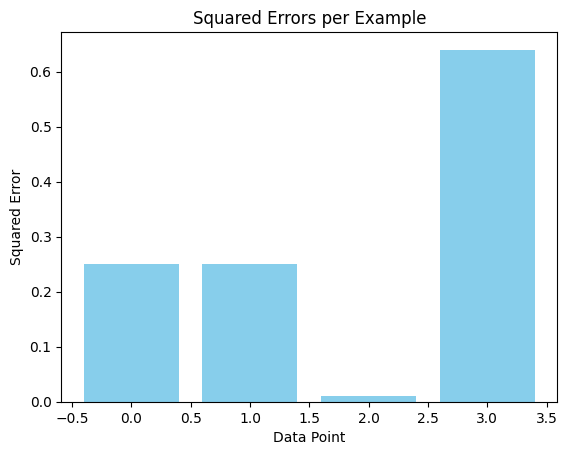

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual values (ground truth)
y_true = np.array([3.0, -0.5, 2.0, 7.0])

# Predicted values by model
y_pred = np.array([2.5, 0.0, 2.1, 7.8])

# MSE function
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Calculate
mse = mean_squared_error(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")




errors = y_true - y_pred
squared_errors = errors ** 2

plt.bar(range(len(y_true)), squared_errors, color='skyblue')
plt.title("Squared Errors per Example")
plt.xlabel("Data Point")
plt.ylabel("Squared Error")
plt.show()


##Test Lab : Linear Regression using 2 Features



```
Prediction:  ŷ = wx + b
Cost:        MSE = (1/n) * Σ(y - ŷ)^2
Goal:        Find best w and b that minimize MSE
```



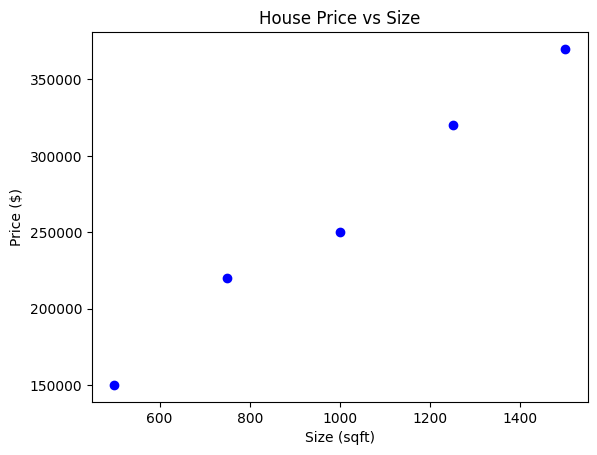

In [ ]:
# 📍 Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 📍 Step 2: Simulate Some Data
# Let's say this is house size (in square feet)
X = np.array([500, 750, 1000, 1250, 1500])  # input feature
y = np.array([150000, 220000, 250000, 320000, 370000])  # price in $
# y_easy = np.array([150000, 200000, 250000, 300000, 350000])  # price in $ This dataset is easy to predict because the pattern so obvious

# Visualize
plt.scatter(X, y, color='blue')
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.title("House Price vs Size")
plt.show()

## Using manual parameter tuning

Predicted Prices: [150000 200000 250000 300000 350000]
Mean Squared Error: 240000000.00


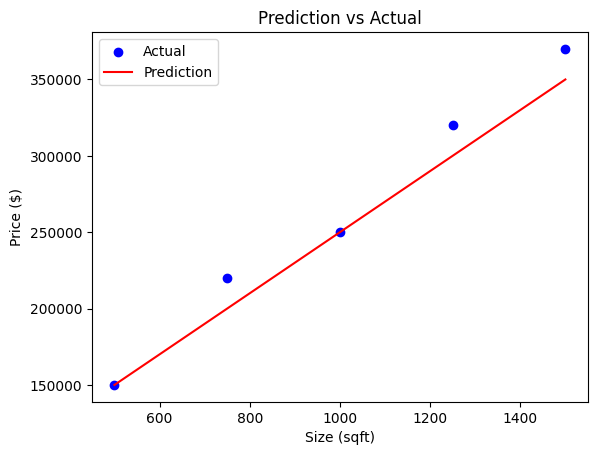

In [ ]:
# 📍 Step 3: Define the Prediction Function
# y_pred = w * x + b

def predict(X, w, b):
    return w * X + b

# 📍 Step 4: Define the Cost Function (MSE)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 📍 Step 5: Try a Sample Prediction and Compute Cost

# Try some random weights (Hyperparameter) that we need to tune based on model (this is random) can be manually tuned or we can find best weight and bias
# Using gradient descent

w = 200  # $200 per sqft
b = 50000  # base price

y_pred = predict(X, w, b)
mse = mean_squared_error(y, y_pred)

print(f"Predicted Prices: {y_pred}")
print(f"Mean Squared Error: {mse:.2f}")


# 📍 Step 6: Plot Prediction Line vs True Data
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Prediction')
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.title("Prediction vs Actual")
plt.legend()
plt.show()



[ 500  750 1000 1250 1500 2200 3300 3500]
New Square Footage Values: [2200 3300 3500]
Predicted Prices for New Sizes: [490000 710000 750000]


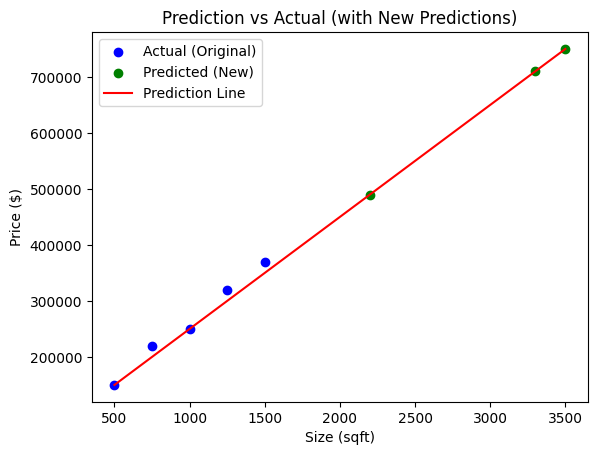

In [ ]:
# Add the new square footage values to the existing X array
X_new = np.array([2200, 3300, 3500])
X_combined = np.concatenate((X, X_new))

print(X_combined)

# Use the predict function with the current w and b to get predictions for the new sizes
y_pred_new = predict(X_new, w, b)

print(f"New Square Footage Values: {X_new}")
print(f"Predicted Prices for New Sizes: {y_pred_new}")

# You can also visualize these new predictions on the plot
plt.scatter(X, y, color='blue', label='Actual (Original)')
plt.scatter(X_new, y_pred_new, color='green', label='Predicted (New)') # Plot new predictions
plt.plot(X_combined, predict(X_combined, w, b), color='red', label='Prediction Line') # Plot the full line
plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.title("Prediction vs Actual (with New Predictions)")
plt.legend()
plt.show()

## Optimizer Implementation using Gradient Descent

In gradient descent you only need to tune learning rate and epoch (iteration)

Epoch 0: Cost = 1.0000, w = 0.0199, b = 0.0000
Epoch 100: Cost = 0.0283, w = 0.8653, b = 0.0000
Epoch 200: Cost = 0.0112, w = 0.9774, b = 0.0000
Epoch 300: Cost = 0.0109, w = 0.9923, b = 0.0000
Epoch 400: Cost = 0.0109, w = 0.9943, b = 0.0000
Epoch 500: Cost = 0.0109, w = 0.9945, b = 0.0000
Epoch 600: Cost = 0.0109, w = 0.9946, b = 0.0000
Epoch 700: Cost = 0.0109, w = 0.9946, b = 0.0000
Epoch 800: Cost = 0.0109, w = 0.9946, b = 0.0000
Epoch 900: Cost = 0.0109, w = 0.9946, b = 0.0000

🎯 Final model: y = 0.9946x + 0.0000


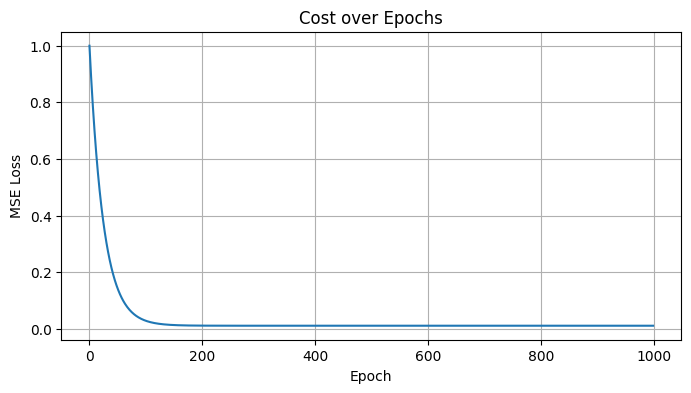

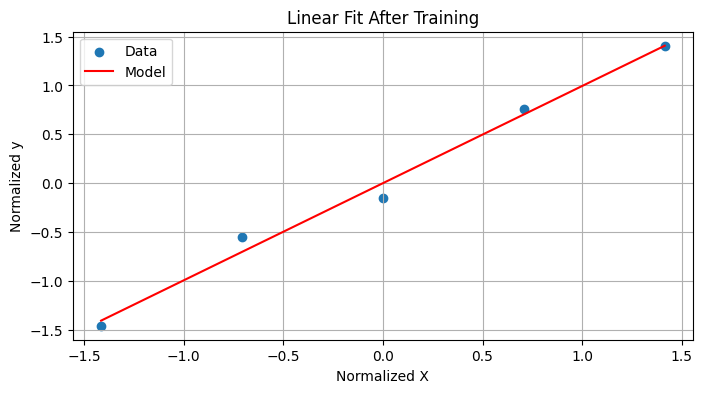

In [ ]:
# Gradient computation
def compute_gradients(x, y, y_pred):
    n = len(x)
    dw = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)
    return dw, db

def normalize(array):
    """Normalize to mean 0 and std 1"""
    return (array - np.mean(array)) / np.std(array)

# ----------------------------
# Training Function
# ----------------------------

def train(x, y, learning_rate=0.01, epochs=100):
    w, b = 0.0, 0.0
    cost_history = []

    for epoch in range(epochs):
        y_pred = predict(x, w, b)
        cost = mean_squared_error(y, y_pred)
        dw, db = compute_gradients(x, y, y_pred)

        # Update weights
        w -= learning_rate * dw
        b -= learning_rate * db

        cost_history.append(cost)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Cost = {cost:.4f}, w = {w:.4f}, b = {b:.4f}")

    return w, b, cost_history


# ----------------------------
# Main Execution
# ----------------------------

# Normalize input and output
X_norm = normalize(X)
y_norm = normalize(y)

# Train the model
w, b, costs = train(X_norm, y_norm, learning_rate=0.01, epochs=1000)

print(f"\n🎯 Final model: y = {w:.4f}x + {b:.4f}")

# ----------------------------
# Visualize Cost Over Time
# ----------------------------

plt.figure(figsize=(8, 4))
plt.plot(costs)
plt.title("Cost over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# ----------------------------
# Visualize Fit
# ----------------------------

plt.figure(figsize=(8, 4))
plt.scatter(X_norm, y_norm, label='Data')
plt.plot(X_norm, predict(X_norm, w, b), color='red', label='Model')
plt.title("Linear Fit After Training")
plt.xlabel("Normalized X")
plt.ylabel("Normalized y")
plt.legend()
plt.grid(True)
plt.show()

## This use case above is good , but too many epoch so we waste a lot of computational resource , in next step i will implement "Early Stop" so it will stop when the `cost` is optimal enough.

📉 Epoch 0: Cost = 1.000000, w = 0.0199, b = 0.0000
📉 Epoch 10: Cost = 0.671216, w = 0.1982, b = 0.0000
📉 Epoch 20: Cost = 0.451717, w = 0.3439, b = 0.0000
📉 Epoch 30: Cost = 0.305178, w = 0.4629, b = 0.0000
📉 Epoch 40: Cost = 0.207347, w = 0.5601, b = 0.0000
📉 Epoch 50: Cost = 0.142035, w = 0.6396, b = 0.0000
📉 Epoch 60: Cost = 0.098432, w = 0.7045, b = 0.0000
📉 Epoch 70: Cost = 0.069322, w = 0.7576, b = 0.0000
📉 Epoch 80: Cost = 0.049888, w = 0.8009, b = 0.0000
📉 Epoch 90: Cost = 0.036914, w = 0.8364, b = 0.0000
📉 Epoch 100: Cost = 0.028252, w = 0.8653, b = 0.0000
📉 Epoch 110: Cost = 0.022469, w = 0.8889, b = 0.0000
📉 Epoch 120: Cost = 0.018609, w = 0.9083, b = 0.0000
📉 Epoch 130: Cost = 0.016031, w = 0.9240, b = 0.0000
📉 Epoch 140: Cost = 0.014311, w = 0.9369, b = 0.0000
📉 Epoch 150: Cost = 0.013162, w = 0.9475, b = 0.0000
📉 Epoch 160: Cost = 0.012395, w = 0.9561, b = 0.0000
📉 Epoch 170: Cost = 0.011883, w = 0.9631, b = 0.0000
📉 Epoch 180: Cost = 0.011541, w = 0.9689, b = 0.0000
📉 Ep

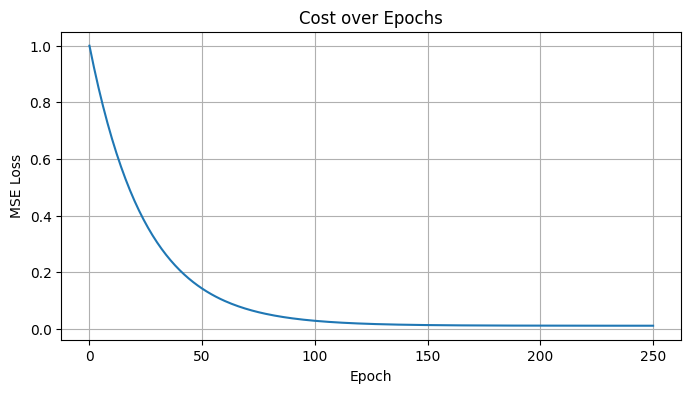

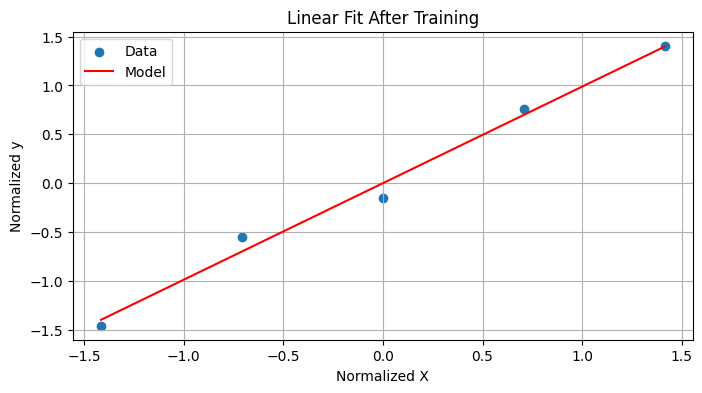

In [ ]:
# Gradient computation
def compute_gradients(x, y, y_pred):
    n = len(x)
    dw = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)
    return dw, db

def normalize(array):
    """Normalize to mean 0 and std 1"""
    return (array - np.mean(array)) / np.std(array)

# ----------------------------
# Training Function
# ----------------------------

def train(x, y, learning_rate=0.01, epochs=100, early_stop_threshold=1e-6, patience=10):
    w, b = 0.0, 0.0
    cost_history = []
    best_cost = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        y_pred = predict(x, w, b)
        cost = mean_squared_error(y, y_pred)
        dw, db = compute_gradients(x, y, y_pred)

        # Update weights
        w -= learning_rate * dw
        b -= learning_rate * db

        cost_history.append(cost)

        # Patience-based early stopping
        if best_cost - cost < early_stop_threshold:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch}")
                print(f"📉 Cost = {cost:.6f}, w = {w:.4f}, b = {b:.4f}")
                break
        else:
            best_cost = cost
            patience_counter = 0

        # Log every x epochs
        if epoch % 10 == 0:
            print(f"📉 Epoch {epoch}: Cost = {cost:.6f}, w = {w:.4f}, b = {b:.4f}")

    # Ensure return always happens
    return w, b, cost_history




# ----------------------------
# Main Execution
# ----------------------------

# Normalize input and output
X_norm = normalize(X)
y_norm = normalize(y)

# Train the model
w, b, costs = train(X_norm, y_norm, learning_rate=0.01, epochs=1000, early_stop_threshold=1e-5, patience=5)


print(f"\n🎯 Final model: y = {w:.4f}x + {b:.4f}")

# ----------------------------
# Visualize Cost Over Time
# ----------------------------

plt.figure(figsize=(8, 4))
plt.plot(costs)
plt.title("Cost over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# ----------------------------
# Visualize Fit
# ----------------------------

plt.figure(figsize=(8, 4))
plt.scatter(X_norm, y_norm, label='Data')
plt.plot(X_norm, predict(X_norm, w, b), color='red', label='Model')
plt.title("Linear Fit After Training")
plt.xlabel("Normalized X")
plt.ylabel("Normalized y")
plt.legend()
plt.grid(True)
plt.show()

## Multi Linear Regression

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target  # X: features, y: house value in 100,000$

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df_housing = pd.DataFrame(X, columns=data.feature_names)
df_housing.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Standarize the dataset

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Initialize params

n_features = X_train.shape[1]
weights = np.zeros(n_features)
bias = 0.0

# Initiate MSE
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_gradients(X, y, y_pred):
    n = len(y)
    dw = (-2 / n) * X.T @ (y - y_pred)
    db = (-2 / n) * np.sum(y - y_pred)
    return dw, db

print(n_features)
print(weights)
print(bias)


8
[0. 0. 0. 0. 0. 0. 0. 0.]
0.0


Epoch 0: MSE = 0.5179
Epoch 50: MSE = 0.5179
Epoch 100: MSE = 0.5179
Epoch 150: MSE = 0.5179
Epoch 200: MSE = 0.5179
Epoch 250: MSE = 0.5179
Epoch 300: MSE = 0.5179
Epoch 350: MSE = 0.5179
Epoch 400: MSE = 0.5179
Epoch 450: MSE = 0.5179
Epoch 500: MSE = 0.5179
Epoch 550: MSE = 0.5179
Epoch 600: MSE = 0.5179
Epoch 650: MSE = 0.5179
Epoch 700: MSE = 0.5179
Epoch 750: MSE = 0.5179
Epoch 800: MSE = 0.5179
Epoch 850: MSE = 0.5179
Epoch 900: MSE = 0.5179
Epoch 950: MSE = 0.5179
Epoch 1000: MSE = 0.5179
Epoch 1050: MSE = 0.5179
Epoch 1100: MSE = 0.5179
Epoch 1150: MSE = 0.5179
Epoch 1200: MSE = 0.5179
Epoch 1250: MSE = 0.5179
Epoch 1300: MSE = 0.5179
Epoch 1350: MSE = 0.5179
Epoch 1400: MSE = 0.5179
Epoch 1450: MSE = 0.5179
Epoch 1500: MSE = 0.5179
Epoch 1550: MSE = 0.5179
Epoch 1600: MSE = 0.5179
Epoch 1650: MSE = 0.5179
Epoch 1700: MSE = 0.5179
Epoch 1750: MSE = 0.5179
Epoch 1800: MSE = 0.5179
Epoch 1850: MSE = 0.5179
Epoch 1900: MSE = 0.5179
Epoch 1950: MSE = 0.5179


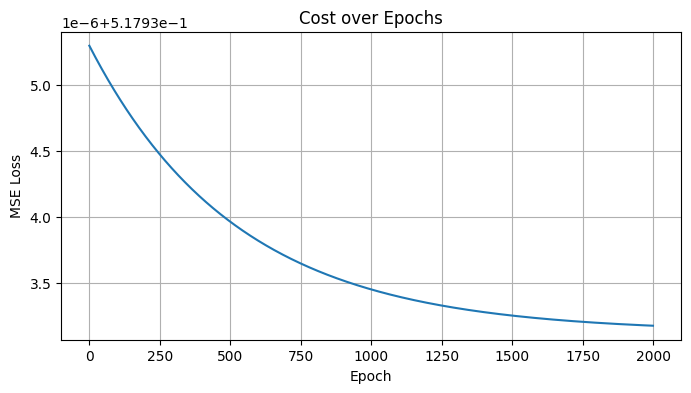

In [ ]:
import matplotlib.pyplot as plt

learning_rate = 0.01
n_epochs = 2000
cost_history = [] # Initialize cost history list

for epoch in range(n_epochs):
    y_pred = X_train @ weights + bias
    cost = mse(y_train, y_pred)

    dw, db = compute_gradients(X_train, y_train, y_pred)
    weights -= learning_rate * dw
    bias -= learning_rate * db
    cost_history.append(cost) # Append cost to history

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: MSE = {cost:.4f}")

# Visualize cost over epochs
plt.figure(figsize=(8, 4))
plt.plot(cost_history)
plt.title("Cost over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [ ]:
y_test_pred = X_test @ weights + bias
test_mse = mse(y_test, y_test_pred)
print(f"Test MSE: {test_mse:.4f}")

Test MSE: 0.5559
